In [1]:
import os
os.chdir("/resnick/groups/GoentoroLab/LiY/illumina")
os.getcwd()

'/resnick/groups/GoentoroLab/LiY/illumina'

In [2]:
from pathlib import Path
import re
import anndata
import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.decomposition import TruncatedSVD
from scipy import sparse, io
%matplotlib inline

/home/yutian/miniconda3/envs/sc_env/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [3]:
random_seed = 0

In [ ]:
#Read raw data files
base = Path("/resnick/groups/GoentoroLab/LiY/illumina/kb_out_v4/collected_laneMerged_h5ad")

adatas = {}

for p in sorted(base.glob("*_laneMerged.h5ad")):
    name = p.stem  # Goentoro_XXX_laneMerged
    print("reading:", name)
    adatas[name] = ad.read_h5ad(p)

print("Loaded:", len(adatas))

In [13]:
import numpy as np
import pandas as pd

rows = []

for name, adata in adatas.items():
    total_umi = np.array(adata.X.sum()).item()
    rows.append({
        "sample": name,
        "n_cells": adata.n_obs,
        "total_raw_UMI": int(total_umi),
        "mean_UMI_per_cell": float(total_umi / adata.n_obs)
    })

pd.DataFrame(rows).sort_values("sample")


,sample,n_cells,total_raw_UMI,mean_UMI_per_cell
0,Goentoro_Dec15FTC_S1_laneMerged,462430,27935549,60.410330
1,Goentoro_Dec15PAT_S2_laneMerged,625736,31329450,50.068160
2,Goentoro_Dec22FTC_S3_laneMerged,460464,25442919,55.254958
3,Goentoro_Dec22PAT_S4_laneMerged,548206,26122925,47.651658
4,Goentoro_Nov24FTC_S3_laneMerged,457298,21664797,47.375665
5,Goentoro_Nov24PAT_S4_laneMerged,589107,24714644,41.952725
6,Goentoro_Nov6FTC_S1_laneMerged,331853,13707066,41.304632
7,Goentoro_Nov6PAT_S2_laneMerged,522352,23029983,44.089011


In [5]:
#Annotate gene names to Fbgnxxxxx
gene_file = Path("/resnick/groups/GoentoroLab/LiY/illumina/kb_out_v4/collected_laneMerged_h5ad/cells_x_genes.genes.names.txt")

with gene_file.open() as f:
    gene_names = [line.strip() for line in f]

for name, a in adatas.items():
#    if len(gene_names) != a.n_vars:
#        raise ValueError(f"{name}: gene_names({len(gene_names)}) != n_vars({a.n_vars})")

    a.var["gene_id"] = a.var_names.astype(str)
    a.var["gene_name_raw"] = gene_names
    a.var["gene_name"] = [
        re.sub(r"\{\}\d*$", "", g) for g in gene_names
    ]

In [6]:
#Calculate mt counts
for a in adatas.values():
    a.var['is_mito']=a.var["gene_name"].str.startswith("mt:")
    sc.pp.calculate_qc_metrics(a, qc_vars=['is_mito'],log1p=False, percent_top=None, inplace=True)

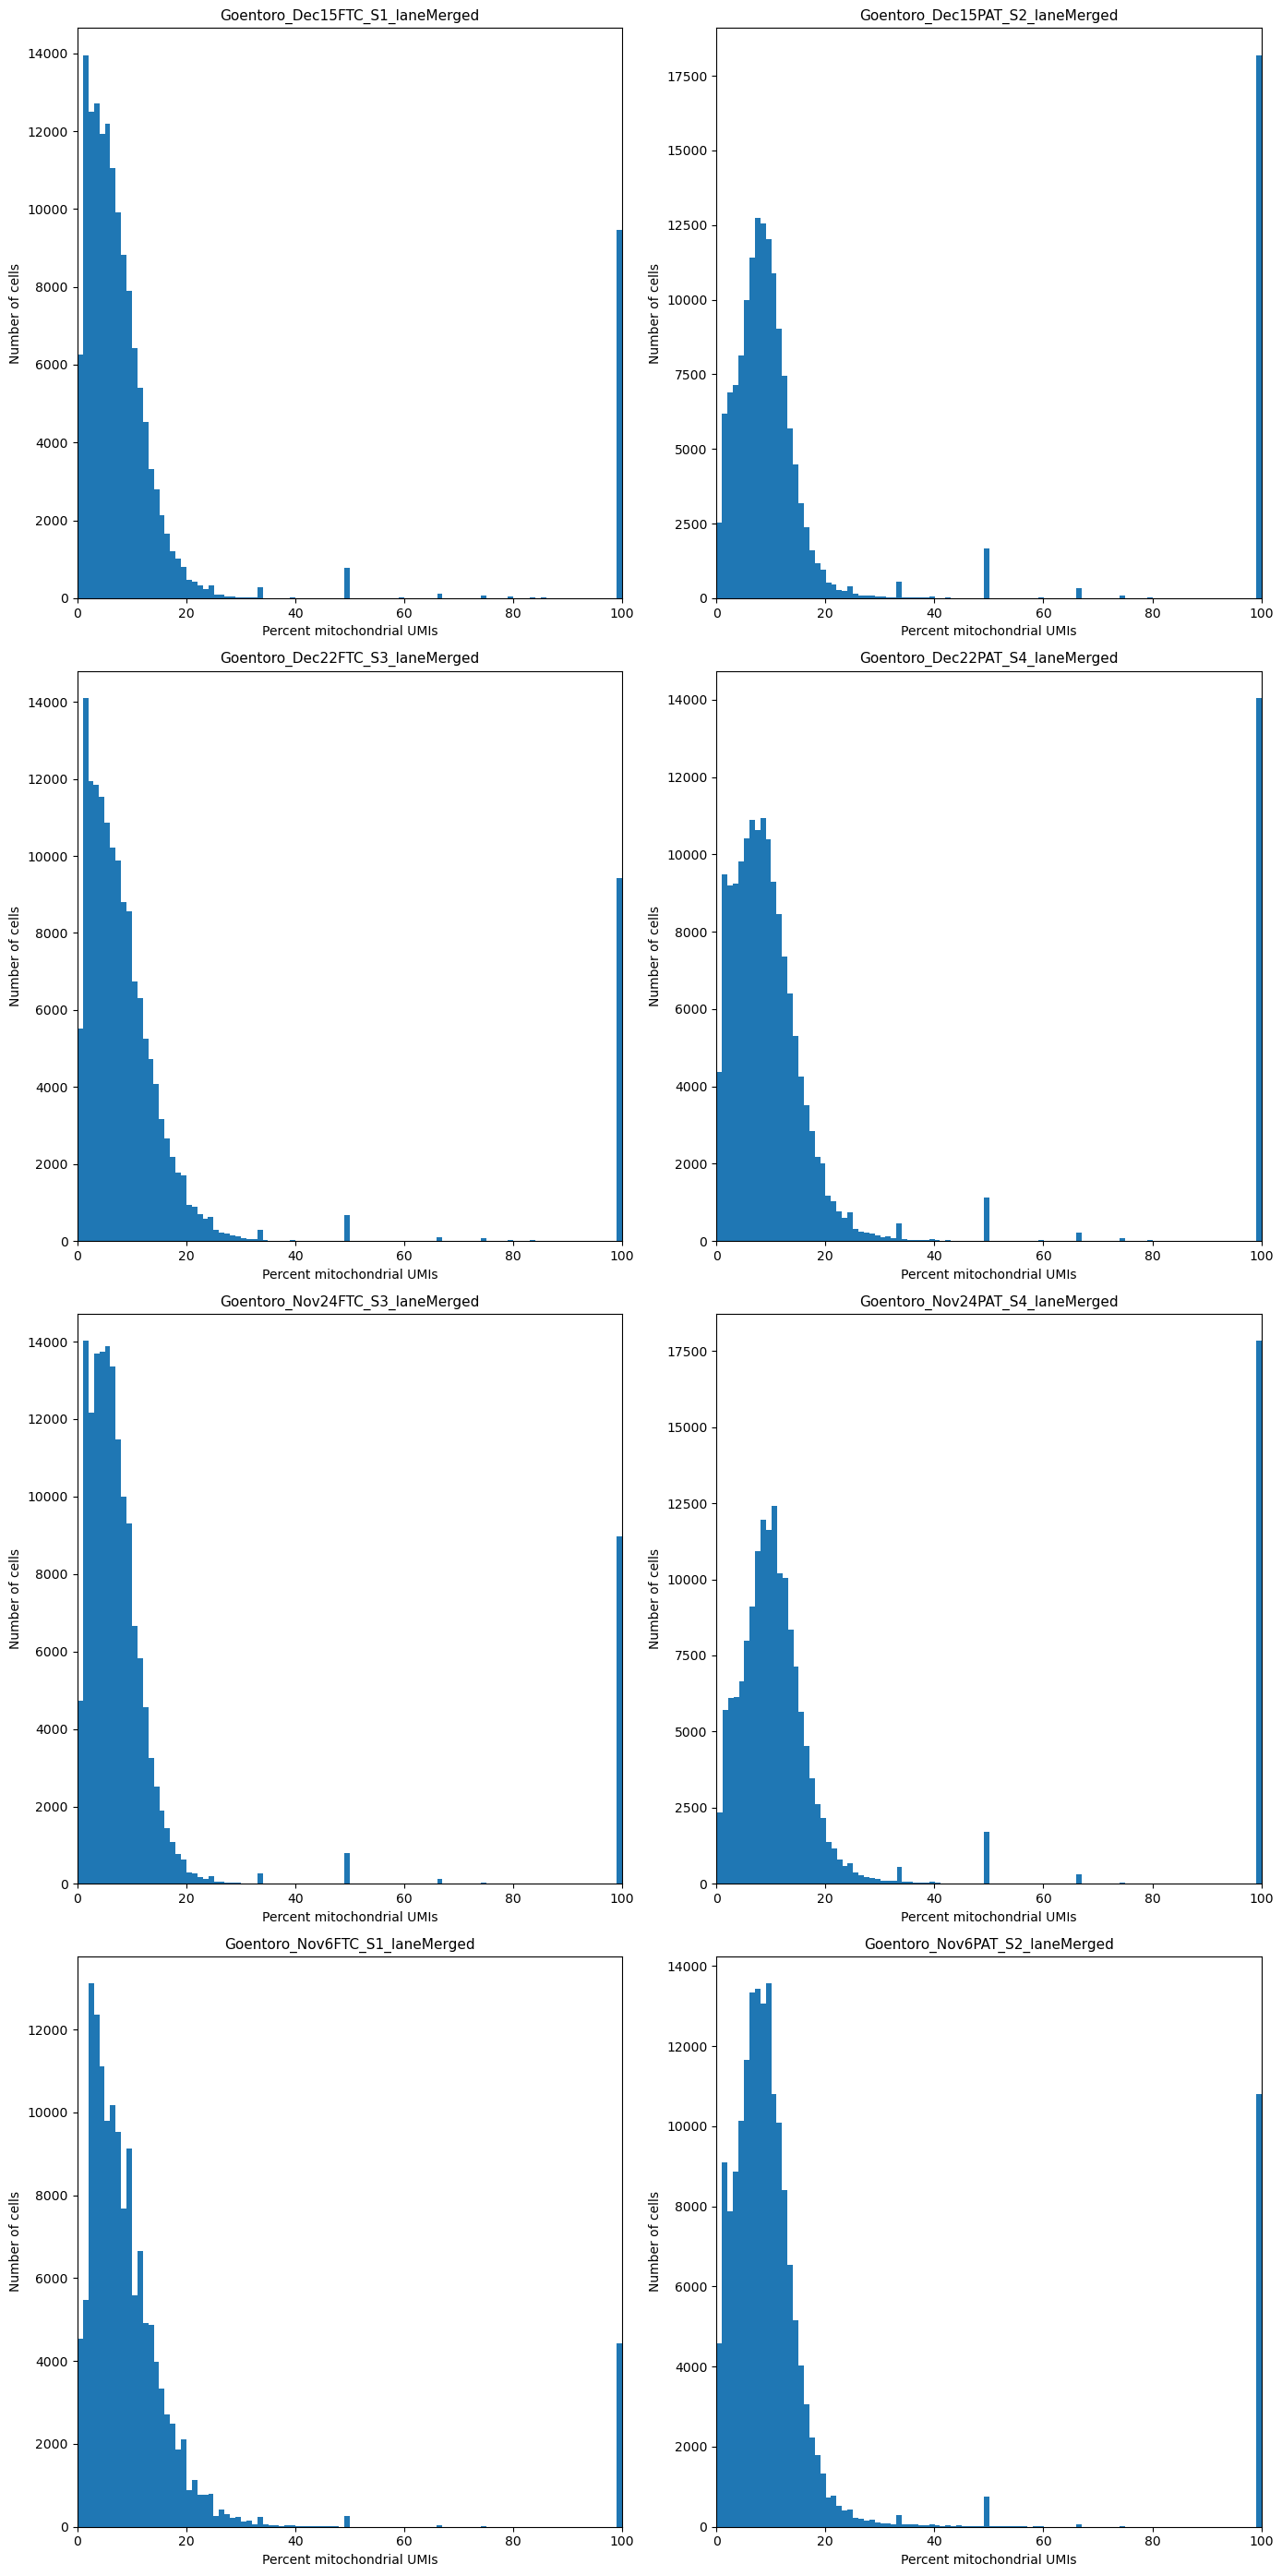

In [7]:
#Verify mitochondria plots
fig, axes = plt.subplots(4, 2, figsize=(14, 28))
axes = axes.flatten()

names = list(adatas.keys())

for ax, name in zip(axes, names):
    a = adatas[name]

    x = a.obs["pct_counts_is_mito"]
    x_plot = x[x > 0]   

    ax.hist(x_plot, bins=100)

    title = name.replace("_counts_unfiltered_merged", "")
    ax.set_xlim(0, 100)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Percent mitochondrial UMIs")
    ax.set_ylabel("Number of cells")

plt.tight_layout()
plt.savefig("Histogram_mito.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
cutoff_umi = 500
cutoff_gene = 200
cutoff_mito = 5
doublet_score_cutoff = 0.3

filtered_adatas = {}
scrubbed_adatas = {}

for name, a in adatas.items():
    keep = (
        (a.obs["total_counts"] >= cutoff_umi) &
        (a.obs["n_genes_by_counts"] >= cutoff_gene) &
        (a.obs["pct_counts_is_mito"] <= cutoff_mito)
    )
    a_filt = a[keep].copy()
    filtered_adatas[name] = a_filt

    print(
        f"{name}: {a_filt.n_obs:,} / {a.n_obs:,} cells kept "
        f"[UMI>={cutoff_umi}, genes>={cutoff_gene}, mito<={cutoff_mito}]"
    )

    # scrublet (writes to a_filt.obs)
    sc.pp.scrublet(a_filt, expected_doublet_rate=0.06, random_state=random_seed)

    # hard filter by doublet_score
    keep_singlet = a_filt.obs["doublet_score"] < doublet_score_cutoff
    a_scrub = a_filt[keep_singlet].copy()
    scrubbed_adatas[name] = a_scrub

    nd = int((~keep_singlet).sum())
    print(f"  scrublet: removed {nd:,}/{a_filt.n_obs:,} ({nd/a_filt.n_obs:.1%}) by doublet_score<{doublet_score_cutoff}")

Goentoro_Dec15FTC_S1_laneMerged: 9,236 / 462,430 cells kept [UMI>=500, genes>=200, mito<=5]
  scrublet: removed 11/9,236 (0.1%) by doublet_score<0.3
Goentoro_Dec15PAT_S2_laneMerged: 10,080 / 625,736 cells kept [UMI>=500, genes>=200, mito<=5]
  scrublet: removed 75/10,080 (0.7%) by doublet_score<0.3
Goentoro_Dec22FTC_S3_laneMerged: 7,788 / 460,464 cells kept [UMI>=500, genes>=200, mito<=5]
  scrublet: removed 14/7,788 (0.2%) by doublet_score<0.3
Goentoro_Dec22PAT_S4_laneMerged: 8,451 / 548,206 cells kept [UMI>=500, genes>=200, mito<=5]
  scrublet: removed 38/8,451 (0.4%) by doublet_score<0.3
Goentoro_Nov24FTC_S3_laneMerged: 6,631 / 457,298 cells kept [UMI>=500, genes>=200, mito<=5]
  scrublet: removed 6/6,631 (0.1%) by doublet_score<0.3
Goentoro_Nov24PAT_S4_laneMerged: 6,891 / 589,107 cells kept [UMI>=500, genes>=200, mito<=5]
  scrublet: removed 14/6,891 (0.2%) by doublet_score<0.3
Goentoro_Nov6FTC_S1_laneMerged: 4,237 / 331,853 cells kept [UMI>=500, genes>=200, mito<=5]
  scrublet: re

In [4]:
from pathlib import Path
import scanpy as sc

indir = Path("/resnick/groups/GoentoroLab/LiY/illumina/kb_out_v4/collected_laneMerged_h5ad/scrubbed_h5ad")

scrubbed_adatas = {}

for f in sorted(indir.glob("*_scrubbed.h5ad")):
    name = f.name.replace("_scrubbed.h5ad", "")
    scrubbed_adatas[name] = sc.read_h5ad(f)
    print(f"loaded: {name}, shape={scrubbed_adatas[name].shape}")

print("total samples loaded:", len(scrubbed_adatas))

loaded: Goentoro_Dec15FTC_S1_laneMerged, shape=(9225, 24254)
loaded: Goentoro_Dec15PAT_S2_laneMerged, shape=(10005, 24254)
loaded: Goentoro_Dec22FTC_S3_laneMerged, shape=(7774, 24254)
loaded: Goentoro_Dec22PAT_S4_laneMerged, shape=(8413, 24254)
loaded: Goentoro_Nov24FTC_S3_laneMerged, shape=(6625, 24254)
loaded: Goentoro_Nov24PAT_S4_laneMerged, shape=(6877, 24254)
loaded: Goentoro_Nov6FTC_S1_laneMerged, shape=(4235, 24254)
loaded: Goentoro_Nov6PAT_S2_laneMerged, shape=(7340, 24254)
total samples loaded: 8


In [5]:
import numpy as np
import pandas as pd

rows = []

for name, adata in scrubbed_adatas.items():
    X = adata.X
    
    # UMI per nucleus
    umi_per_cell = np.array(X.sum(axis=1)).ravel()
    
    rows.append({
        "sample": name,
        "n_nuclei": adata.n_obs,
        "total_UMI": int(umi_per_cell.sum()),
        "mean_UMI_per_nucleus": round(umi_per_cell.mean(), 2),
        "median_UMI_per_nucleus": round(np.median(umi_per_cell), 2)
    })

df = pd.DataFrame(rows).sort_values("sample")
df


,sample,n_nuclei,total_UMI,mean_UMI_per_nucleus,median_UMI_per_nucleus
0,Goentoro_Dec15FTC_S1_laneMerged,9225,12406350,1344.86,942.0
1,Goentoro_Dec15PAT_S2_laneMerged,10005,10409134,1040.39,781.0
2,Goentoro_Dec22FTC_S3_laneMerged,7774,11254850,1447.76,982.5
3,Goentoro_Dec22PAT_S4_laneMerged,8413,8830541,1049.63,793.0
4,Goentoro_Nov24FTC_S3_laneMerged,6625,8603861,1298.70,898.0
5,Goentoro_Nov24PAT_S4_laneMerged,6877,7161689,1041.40,764.0
6,Goentoro_Nov6FTC_S1_laneMerged,4235,5930356,1400.32,937.0
7,Goentoro_Nov6PAT_S2_laneMerged,7340,7402881,1008.57,781.0


In [6]:
# A) parse metadata into each per-sample AnnData (from key name)
for name, a in scrubbed_adatas.items():
    a.obs["sample_id"] = name
    m = re.search(r"Goentoro_(Nov6|Nov24|Dec15|Dec22)(FTC|PAT)", name)
    a.obs["date"] = m.group(1)
    a.obs["condition_group"] = "control" if m.group(2) == "FTC" else "treated"

# B) split + concatenate (control / treated separately)
control_adatas = {k: v for k, v in scrubbed_adatas.items() if "FTC" in k}
treated_adatas = {k: v for k, v in scrubbed_adatas.items() if "PAT" in k}

adata_control = ad.concat(list(control_adatas.values()), join="outer", merge="same", index_unique="-")
adata_treated = ad.concat(list(treated_adatas.values()), join="outer", merge="same", index_unique="-")

print("control:", adata_control.shape)
print("treated:", adata_treated.shape)

# optional sanity
#print(adata_control.obs["date"].value_counts().to_dict())
#print(adata_treated.obs["date"].value_counts().to_dict())

control: (27859, 24254)
treated: (32635, 24254)


In [12]:
import numpy as np

def summarize(adata, name):
    X = adata.X

    # total UMI per cell
    umi = np.array(X.sum(axis=1)).ravel()

    # detected genes per cell
    if hasattr(X, "getnnz"):
        ngenes = X.getnnz(axis=1)
    else:
        ngenes = (X > 0).sum(axis=1)

    print(f"\n{name}")
    print("Cells:", adata.n_obs)
    print("Mean UMI:", round(umi.mean(), 2))
    print("Median UMI:", round(np.median(umi), 2))
    print("Max UMI:", round(umi.max(), 2))
    print("Mean genes:", round(np.mean(ngenes), 2))
    print("Median genes:", round(np.median(ngenes), 2))
    print("Max genes:", round(np.max(ngenes), 2))

summarize(adata_control, "Control (filtered)")
summarize(adata_treated, "Treated (filtered)")



Control (filtered)
Cells: 27859
Mean UMI: 1371.03
Median UMI: 942.0
Max UMI: 106638.0
Mean genes: 476.99
Median genes: 376.0
Max genes: 6114

Treated (filtered)
Cells: 32635
Mean UMI: 1035.83
Median UMI: 779.0
Max UMI: 45699.0
Mean genes: 421.55
Median genes: 357.0
Max genes: 5391


In [22]:
from pathlib import Path

outdir = Path("obs_exports")
outdir.mkdir(exist_ok=True)

# control
adata_control.obs.to_csv(outdir / "control_obs_processed.csv", index=True)

# treated
adata_treated.obs.to_csv(outdir / "treated_obs_processed.csv", index=True)

print("saved:",
      outdir / "control_obs_processed.csv",
      outdir / "treated_obs_processed.csv")


saved: obs_exports/control_obs_processed.csv obs_exports/treated_obs_processed.csv


In [9]:
print(adata_control.n_vars, adata_treated.n_vars, next(iter(unf.values())).n_vars)

24254 24254 24254


In [7]:
def prep_sc(adata):
    # 1) gene filter
    sc.pp.filter_genes(adata, min_cells=3)
    # 2) normalize + log + raw snapshot
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.log1p(adata)
    adata.raw = adata
    # 3) HVGs (batch-aware)
    sc.pp.highly_variable_genes(
        adata,
        min_mean=0.01,
        max_mean=8,
        min_disp=1,
        n_bins=20,
        flavor="seurat",
        batch_key="sample_id",
    )
    # 4) scale + PCA
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(
        adata,
        mask_var="highly_variable",
        svd_solver="arpack",
        random_state=random_seed,
    )
    # 5) neighbors
    sc.pp.neighbors(
        adata,
        n_neighbors=30,
        n_pcs=20,
        random_state=random_seed,
    )

    return adata

In [8]:
# run
prep_sc(adata_control)
prep_sc(adata_treated)

/home/yutian/miniconda3/envs/sc_env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/yutian/miniconda3/envs/sc_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/yutian/miniconda3/envs/sc_env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 32635 × 13016
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_is_mito', 'pct_counts_is_mito', 'doublet_score', 'predicted_doublet', 'sample_id', 'date', 'condition_group'
    var: 'gene_id', 'gene_name_raw', 'gene_name', 'is_mito', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

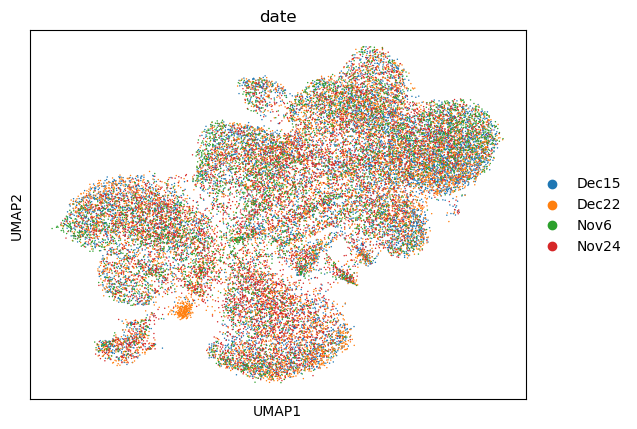

In [9]:
# Plot UMAP
sc.tl.umap(adata_control, random_state = random_seed)
sc.pl.umap(adata_control, color="date", save="control_umap_kbmerged_stringent.png")

/tmp/ipykernel_3038675/2512921067.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_control, resolution=0.6, random_state=random_seed)


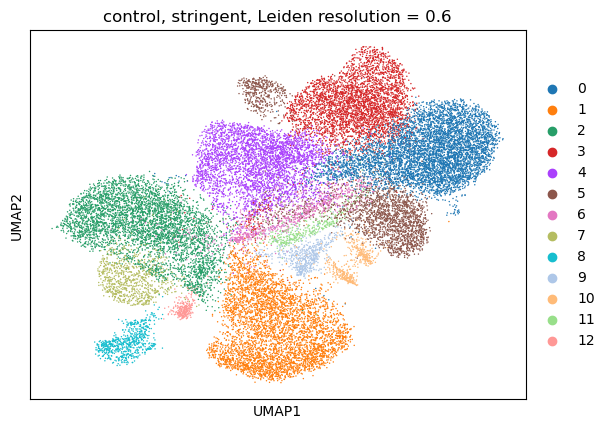

In [10]:
#Plot Leiden
sc.tl.leiden(adata_control, resolution=0.6, random_state=random_seed)
sc.pl.umap(adata_control, 
           color=["leiden"],
           title="control, stringent, Leiden resolution = 0.6",
           save="control_leiden_stringent_0p6.png")

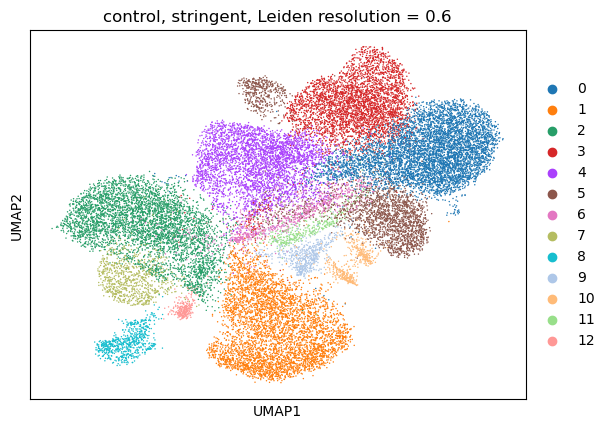

In [10]:
sc.pl.umap(
    adata_control,
    color=["leiden"],
    title="control, stringent, Leiden resolution = 0.6",
    save="control_leiden_stringent_0p6.svg"
)


In [13]:
sc.tl.leiden(adata_control, resolution=0.6, random_state=random_seed)

In [14]:
sc.tl.rank_genes_groups(adata_control, groupby="leiden", method="wilcoxon", use_raw=True)

In [15]:
# ranked genes in each cluster (all ranks)
names = adata_control.uns["rank_genes_groups"]["names"]
groups = names.dtype.names
ranked_fbgn = pd.DataFrame({g: names[g] for g in groups})

# FBgn -> gene_name_raw mapping
fbgn_to_raw = pd.Series(
    adata_control.var["gene_name_raw"].to_numpy(),
    index=adata_control.var_names.astype(str)
).to_dict()

# mapped full table
ranked_symbols = ranked_fbgn.applymap(lambda x: fbgn_to_raw.get(x, x))

/tmp/ipykernel_2552540/988415773.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ranked_symbols = ranked_fbgn.applymap(lambda x: fbgn_to_raw.get(x, x))


In [16]:
# top20 (optional)
top20 = ranked_symbols.iloc[:20, :]
top20

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,CG40006,pum,para,mamo,sls,Su(H),trol,pros,CG13428,mfas,lncRNA:CR44298,Wnt6,mt:ATPase6
1,l(3)80Fg,Ten-m,Sh,vir-1,bt,Rbp6,Rbfox1,para,CG10175,CG17646,asRNA:CR44297,cv-c,CG13428
2,CG5973,Ppn,Rdl,mgl,up,Vmat,Fas2,Sh,mgl,sog,ldd,fax,EbpIII
3,CG41520,Prosap,Syt1,Sp1,Mhc,sv,LRP1,slo,ara,copia{}RR48347,CG40006,KrT95D,mt:ND4
4,Myo81F,zfh1,mbl,cv-c,Zasp66,Mnr,Rbp6,jus,CheB38c,CG5162,CG5973,hdly,mt:CoII
5,ldd,shep,nrv3,ldd,SERCA,alpha-Man-Ia,N,trv,beat-IIIc,Cyp18a1,CG41520,scyl,mt:CoI
6,snu,CG17574,jus,knrl,Mf,ITP,Pkc53E,eag,Obp19b,wat,CG11147,dally,mt:ND1
7,Elovl7,pnt,tutl,slf,CG1674,Dys,rst,Nrx-1,CheA84a,Cat,Ets98B,corto,mt:ND5
8,hopper{}6534,Btk,Nrx-1,inaE,bol,app,CG42390,SK,bi,CG46339,grh,kibra,mt:CoIII
9,CG11147,LpR2,CG13954,disco-r,CG43897,disco-r,nuf,mbl,mim,Rbfox1,l(3)80Fg,trol,CG17108


In [31]:
ranked_symbols.to_csv(
    "control_ranked_genes_Leiden.csv",
    index=False
)

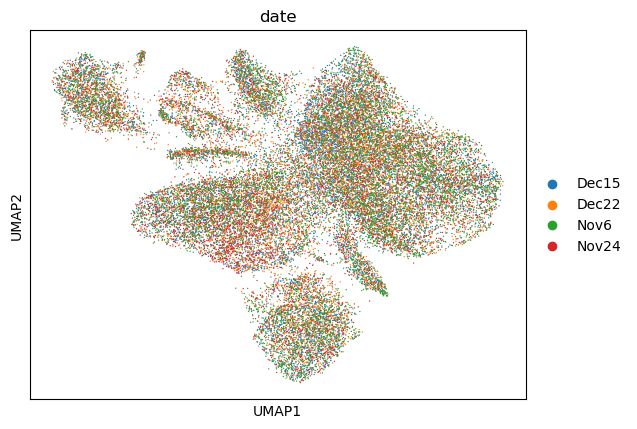

In [11]:
# Plot UMAP
sc.tl.umap(adata_treated, random_state = random_seed)
sc.pl.umap(adata_treated, color="date", save="treated_umap_kbmerged_stringent.png")

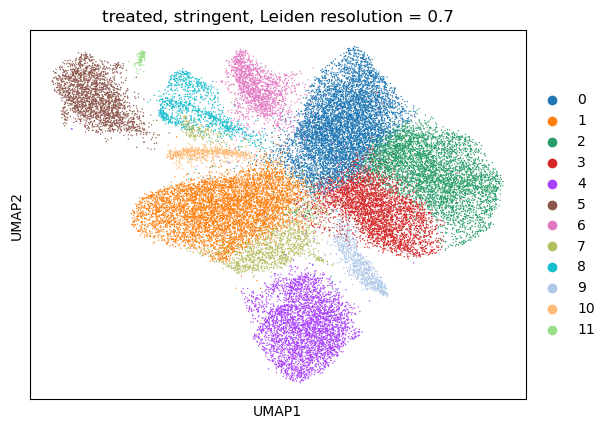

In [12]:
#Plot Leiden
sc.tl.leiden(adata_treated, resolution=0.7, random_state=random_seed)
sc.pl.umap(adata_treated, 
           color=["leiden"],
           title="treated, stringent, Leiden resolution = 0.7",
           save="treated_leiden_stringent_0p7.png")

In [19]:
sc.tl.rank_genes_groups(adata_treated, groupby="leiden", method="wilcoxon", use_raw=True)

In [20]:
# ranked genes in each cluster (all ranks)
names = adata_treated.uns["rank_genes_groups"]["names"]
groups = names.dtype.names
ranked_fbgn = pd.DataFrame({g: names[g] for g in groups})

# FBgn -> gene_name_raw mapping
fbgn_to_raw = pd.Series(
    adata_treated.var["gene_name_raw"].to_numpy(),
    index=adata_treated.var_names.astype(str)
).to_dict()

# mapped full table
ranked_symbols = ranked_fbgn.applymap(lambda x: fbgn_to_raw.get(x, x))

/tmp/ipykernel_2552540/3106630999.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ranked_symbols = ranked_fbgn.applymap(lambda x: fbgn_to_raw.get(x, x))


In [21]:
# top20 (optional)
top20 = ranked_symbols.iloc[:20, :]
top20

,0,1,2,3,4,5,6,7,8,9,10,11
0,CG40006,sls,mgl,CG42390,pum,para,Mnr,lncRNA:alphagamma-element:CR32865,Fas2,mfas,Wnt6,jeb
1,Elovl7,bt,mamo,dpy,Ten-m,Sh,Rbp6,Hsp68,sog,CG31689,KrT95D,bru3
2,CG41520,Mhc,vir-1,raw,LpR2,Rdl,alpha-Man-Ia,Hsp26,Tsf1,Toll-7,fax,trv
3,ldd,dnc,CG17839,cv-c,zfh1,CG31221,Su(H),Hsp83,pAbp,CG3655,hdly,para
4,l(3)80Fg,CG43897,knrl,CG32137,Ppn,Syt1,ITP,Hsp27,Rbfox1,copia{}RR48347,dally,CG31221
5,NFAT,Mf,mtgo,puc,pnt,jus,Dys,Hsp70Bc,Rh50,CG11147,grn,mbl
6,osy,bol,ldd,how,Prosap,mbl,CG3168,Hsp70Bb,nuf,ovo,trol,CG45002
7,EbpIII,Pka-C3,Mnr,Fas3,spir,slo,mgl,stv,N,CG32017,hth,IA-2
8,CG33110,Strn-Mlck,CG32694,Nrg,shep,nrv3,sv,lncRNA:Hsromega,LRP1,Drs,Tollo,pros
9,CG32512,CG44085,lncRNA:CR43314,Moe,RhoGAP71E,tutl,CG17364,DnaJ-1,Nepl15,sog,sNPF-R,Rim


In [26]:
ranked_symbols.to_csv(
    "treated_ranked_genes_Leiden.csv",
    index=False
)

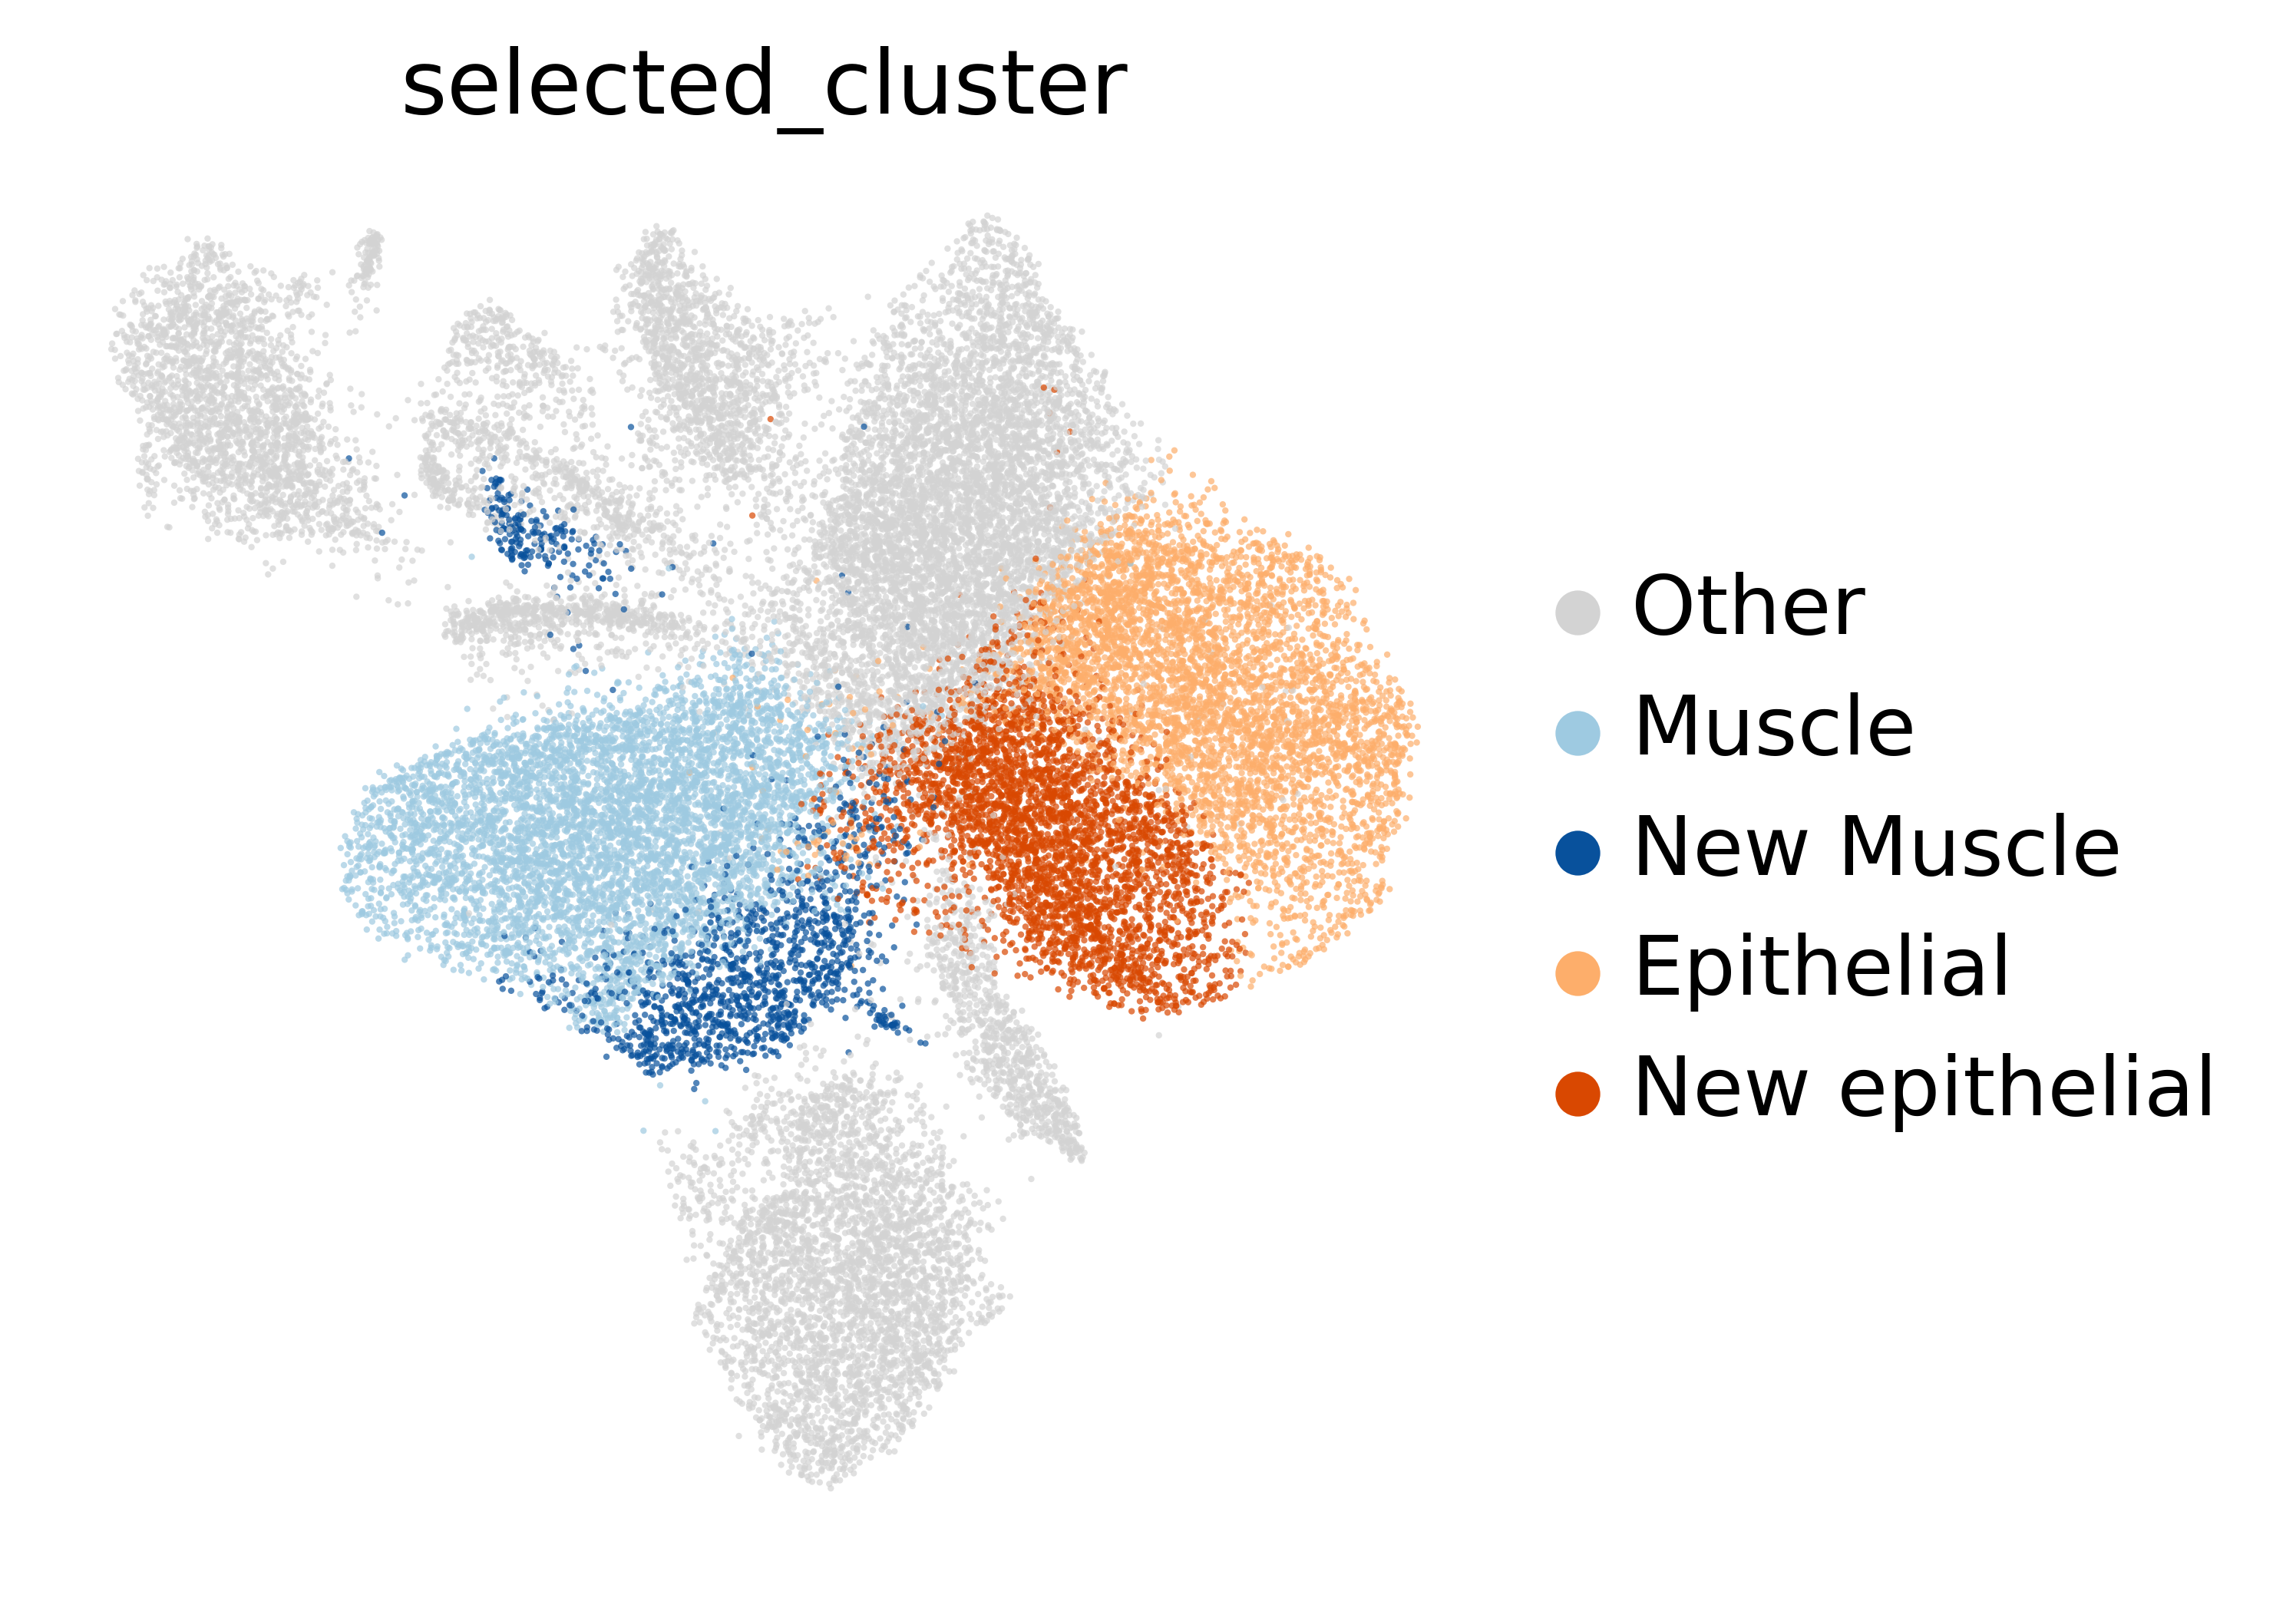

In [14]:
import pandas as pd
import scanpy as sc

cluster_label_map = {
    "1": "Muscle",
    "7": "New Muscle",
    "2": "Epithelial",
    "3": "New epithelial"
}

adata_treated.obs["selected_cluster"] = "Other"

mask = adata_treated.obs["leiden"].astype(str).isin(cluster_label_map.keys())

adata_treated.obs.loc[mask, "selected_cluster"] = (
    adata_treated.obs.loc[mask, "leiden"]
    .astype(str)
    .map(cluster_label_map)
)

adata_treated.obs["selected_cluster"] = pd.Categorical(
    adata_treated.obs["selected_cluster"],
    categories=[
        "Other",
        "Muscle",
        "New Muscle",
        "Epithelial",
        "New epithelial"
    ]
)

palette = {
    "Other": "lightgrey",
    "Muscle": "#9ecae1",
    "New Muscle": "#08519c",
    "Epithelial": "#fdae6b",
    "New epithelial": "#d94801"
}

sc.pl.umap(
    adata_treated,
    color="selected_cluster",
    palette=palette,
    size=4,        
    alpha=0.7,    
    frameon=False,
    save="treated_specific_clusters.png"
)

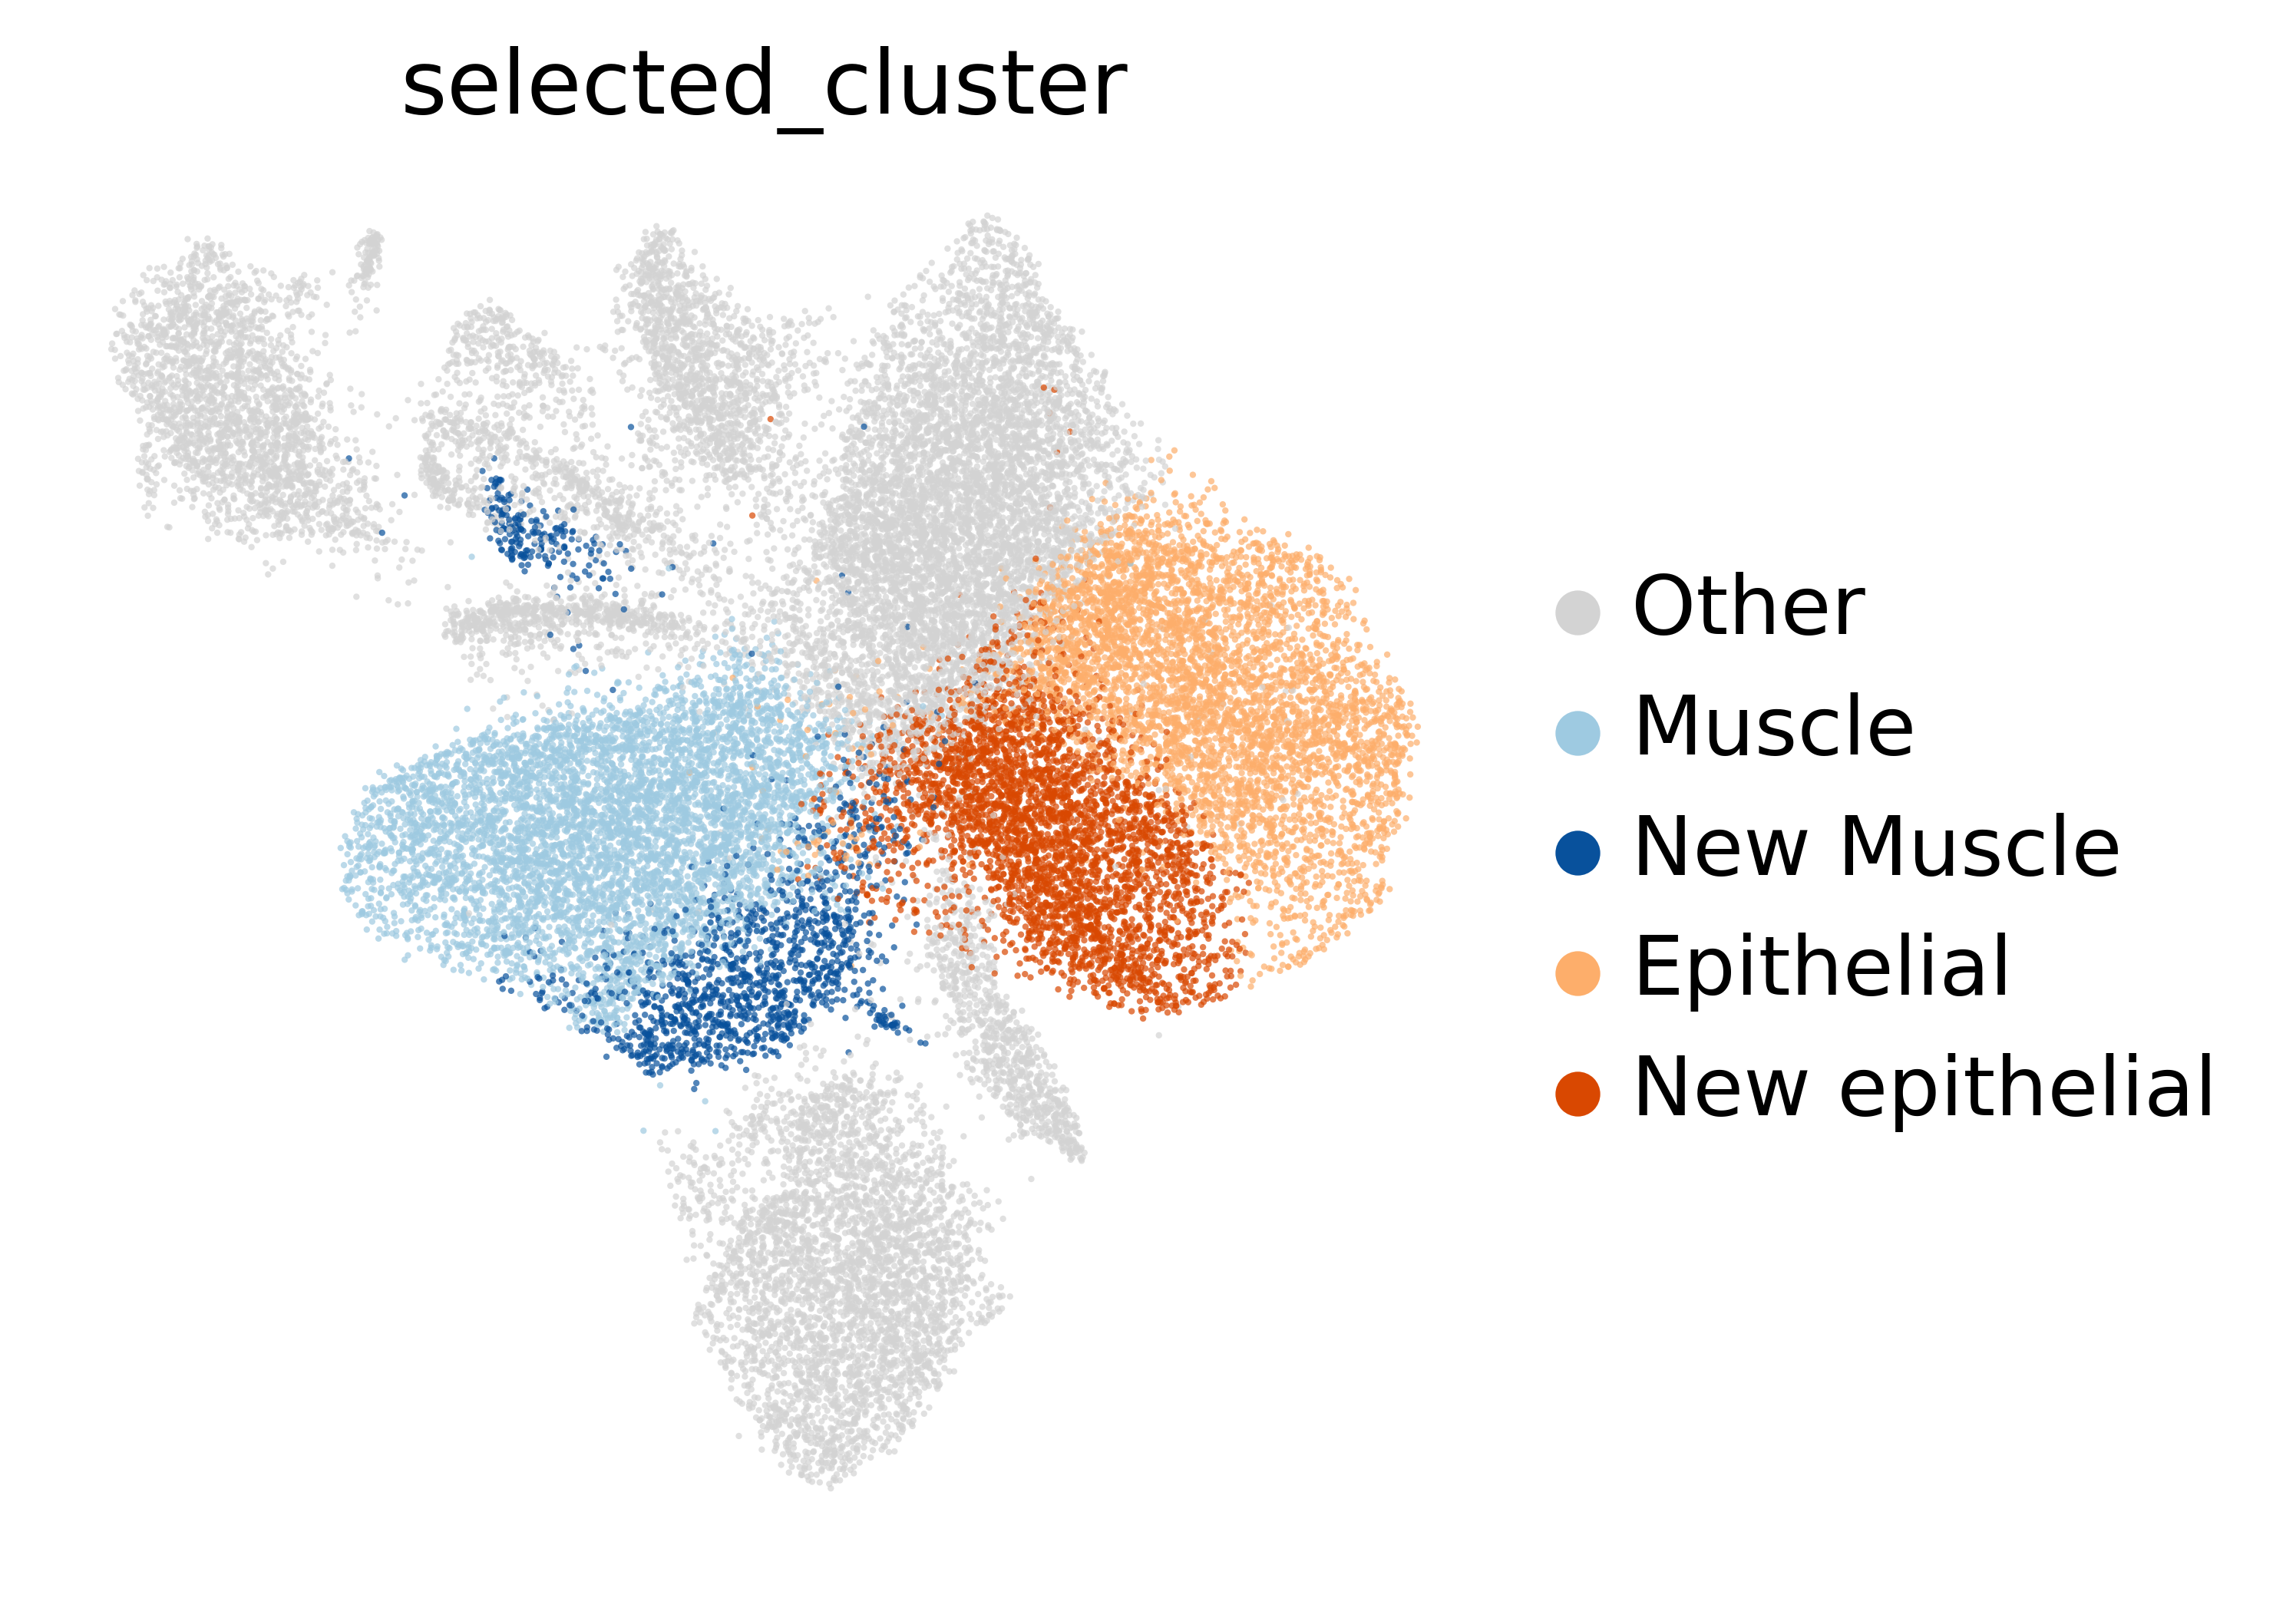

In [15]:
sc.settings.set_figure_params(dpi=300, dpi_save=600, vector_friendly=True)

sc.pl.umap(
    adata_treated,
    color="selected_cluster",
    palette=palette,
    size=4,
    alpha=0.7,
    frameon=False,
    save="treated_specific_clusters.pdf"
)

In [10]:
adata_all = ad.concat(
    [adata_control, adata_treated],
    join="outer",
    merge="same",
    label="concat_group",
    keys=["control", "treated"],
    index_unique=None
)

/home/yutian/miniconda3/envs/sc_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [65]:
# run
prep_sc(adata_all)

/home/yutian/miniconda3/envs/sc_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/yutian/miniconda3/envs/sc_env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 60494 × 14219
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_is_mito', 'pct_counts_is_mito', 'doublet_score', 'predicted_doublet', 'sample_id', 'date', 'condition_group', 'concat_group'
    var: 'gene_id', 'gene_name_raw', 'gene_name', 'is_mito', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

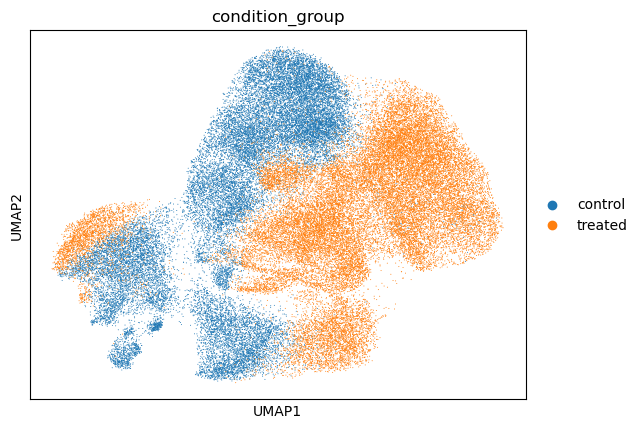

In [67]:
# Plot UMAP
sc.tl.umap(adata_all, random_state = random_seed)
sc.pl.umap(adata_all, color="condition_group", save="all_umap_kbmerged_stringent.png")

In [41]:
cluster_col = "leiden"
cond_col = "condition_group"

adata_t10 = adata_treated[
    adata_treated.obs[cluster_col].astype(str) == "10"
].copy()

adata_c11 = adata_control[
    adata_control.obs[cluster_col].astype(str) == "11"
].copy()

print("treated cluster 10:", adata_t10.n_obs)
print("control cluster 11:", adata_c11.n_obs)

treated cluster 10: 717
control cluster 11: 399


In [8]:
max_nvars = max(a.n_vars for a in adatas.values())

unf = {name: a for name, a in adatas.items() if a.n_vars == max_nvars}

print("recovered unf:", len(unf))
print(sorted(unf.keys()))

recovered unf: 8
['Goentoro_Dec15FTC_S1_laneMerged', 'Goentoro_Dec15PAT_S2_laneMerged', 'Goentoro_Dec22FTC_S3_laneMerged', 'Goentoro_Dec22PAT_S4_laneMerged', 'Goentoro_Nov24FTC_S3_laneMerged', 'Goentoro_Nov24PAT_S4_laneMerged', 'Goentoro_Nov6FTC_S1_laneMerged', 'Goentoro_Nov6PAT_S2_laneMerged']


In [42]:
def pseudobulk_from_unf_dict(subset_adata, unf_dict, date_col="date", sample_col="sample_id"):
    """
    subset_adata: subclusters picked
    unf_dict: {sample_id: unfiltered-ish AnnData} 
    return: genes by dates pseudobulk
    """

    var0 = next(iter(unf_dict.values())).var_names
    for k, a in unf_dict.items():
        if not a.var_names.equals(var0):
            raise ValueError(f"var_names mismatch in {k}")

    out = {}  # date -> summed vector
    for sid, sub_sid in subset_adata.obs.groupby(sample_col):
        if sid not in unf_dict:
            raise KeyError(f"subset contains sample_id not in unf: {sid}")

        a_unf = unf_dict[sid]
        cells = sub_sid.index
        common = a_unf.obs_names.intersection(cells)

        # 10x 后缀兜底：ABC-1 vs ABC
        if len(common) < 0.8 * len(cells):
            unf_base = a_unf.obs_names.to_series().str.replace(r"-\d+$", "", regex=True)
            sub_base = pd.Series(cells, index=cells).str.replace(r"-\d+$", "", regex=True)
            base_to_unf = pd.Series(a_unf.obs_names.values, index=unf_base.values)
            mapped = sub_base.map(base_to_unf).dropna()
            common = pd.Index(mapped.values)

        if len(common) == 0:
            raise ValueError(f"{sid}: matched 0 cells between subset and unf")

        # date=replicate：同一个 sid 应该只有一个 date
        dates = sub_sid[date_col].astype(str).unique()
        if len(dates) != 1:
            raise ValueError(f"{sid}: multiple dates found: {dates}")
        d = dates[0]

        vec = np.asarray(a_unf[common, :].X.sum(axis=0)).ravel()
        out[d] = out.get(d, 0) + vec

    pb = pd.DataFrame(out, index=var0.astype(str))
    return pb

pb_t10_full = pseudobulk_from_unf_dict(adata_t10, unf, date_col="date", sample_col="sample_id")
pb_c11_full = pseudobulk_from_unf_dict(adata_c11, unf, date_col="date", sample_col="sample_id")

print("pb_t10_full:", pb_t10_full.shape, list(pb_t10_full.columns))
print("pb_c11_full:", pb_c11_full.shape, list(pb_c11_full.columns))
print("same genes:", pb_t10_full.index.equals(pb_c11_full.index))

/tmp/ipykernel_901958/633191096.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for sid, sub_sid in subset_adata.obs.groupby(sample_col):
/tmp/ipykernel_901958/633191096.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for sid, sub_sid in subset_adata.obs.groupby(sample_col):


pb_t10_full: (24254, 4) ['Dec15', 'Dec22', 'Nov6', 'Nov24']
pb_c11_full: (24254, 4) ['Dec15', 'Dec22', 'Nov6', 'Nov24']
same genes: True


In [43]:
# 1)
date_order = ['Nov6', 'Nov24', 'Dec15', 'Dec22']
pb_c11 = pb_c11_full.reindex(columns=date_order)
pb_t10 = pb_t10_full.reindex(columns=date_order)

# 2) countData: genes x samples
countData = pd.concat(
    [
        pb_c11.rename(columns=lambda d: f"{d}__control"),
        pb_t10.rename(columns=lambda d: f"{d}__treated"),
    ],
    axis=1
)

# 3) DESeq2 integer counts
countData = countData.round().astype(np.int64)

# 4) colData: samples x covariates
colData = (
    pd.DataFrame({"sample": countData.columns})
      .assign(date=lambda d: d["sample"].str.split("__").str[0])
      .assign(condition_group=lambda d: d["sample"].str.split("__").str[1])
      .set_index("sample")
)
colData = colData.loc[countData.columns]

print("countData:", countData.shape)
print("colData:", colData.shape)
print(colData)

countData: (24254, 8)
colData: (8, 2)
                 date condition_group
Nov6__control    Nov6         control
Nov24__control  Nov24         control
Dec15__control  Dec15         control
Dec22__control  Dec22         control
Nov6__treated    Nov6         treated
Nov24__treated  Nov24         treated
Dec15__treated  Dec15         treated
Dec22__treated  Dec22         treated


In [82]:
# genes x samples
countData.to_csv(
    "countData_t10_vs_c11.tsv",
    sep="\t"
)

# samples x covariates
colData.to_csv(
    "colData_t10_vs_c11.tsv",
    sep="\t"
)

In [12]:
def pseudobulk_mapback_by_date(adata, unf, date_col="date", sample_col="sample_id"):
    var0 = next(iter(unf.values())).var_names
    out = {}

    for sid, sub in adata.obs.groupby(sample_col):
        a_unf = unf[sid]

        cells = sub.index
        common = a_unf.obs_names.intersection(cells)

        if len(common) == 0:
            unf_base = a_unf.obs_names.to_series().str.replace(r"-\d+$", "", regex=True)
            sub_base = pd.Series(cells, index=cells).str.replace(r"-\d+$", "", regex=True)
            base_to_unf = pd.Series(a_unf.obs_names.values, index=unf_base.values)
            mapped = sub_base.map(base_to_unf).dropna()
            common = pd.Index(mapped.values)

        if len(common) == 0:
            raise ValueError(f"{sid}: 0 matched cells")

        d = sub[date_col].astype(str).unique()
        if len(d) != 1:
            raise ValueError(f"{sid}: multiple dates {d}")
        d = d[0]

        vec = np.asarray(a_unf[common].X.sum(axis=0)).ravel()
        out[d] = out.get(d, 0) + vec

    return pd.DataFrame(out, index=var0).astype("int64")


In [14]:
pb_ctrl_full = pseudobulk_mapback_by_date(adata_control, unf)
pb_tr_full  = pseudobulk_mapback_by_date(adata_treated,  unf)

date_order = ["Nov6", "Nov24", "Dec15", "Dec22"]

pb_ctrl = pb_ctrl_full.reindex(columns=date_order)
pb_tr  = pb_tr_full.reindex(columns=date_order)

countData = pd.concat(
    [
        pb_ctrl.rename(columns=lambda d: f"{d}__control"),
        pb_tr.rename(columns=lambda d: f"{d}__treated"),
    ],
    axis=1
).astype("int64")


In [16]:
colData = (
    pd.DataFrame(index=countData.columns)
      .assign(date=lambda d: d.index.to_series().str.split("__").str[0])
      .assign(condition_group=lambda d: d.index.to_series().str.split("__").str[1])
)

assert colData.index.equals(countData.columns)
print("colData:", colData.shape)
print(colData)


colData: (8, 2)
                 date condition_group
Nov6__control    Nov6         control
Nov24__control  Nov24         control
Dec15__control  Dec15         control
Dec22__control  Dec22         control
Nov6__treated    Nov6         treated
Nov24__treated  Nov24         treated
Dec15__treated  Dec15         treated
Dec22__treated  Dec22         treated


In [17]:
assert list(colData.index) == list(countData.columns)


In [19]:
sample = "Nov6__control"
date, cond = sample.split("__")
adata = adata_control if cond == "control" else adata_treated

def match_cells(a_unf, cells):
    common = a_unf.obs_names.intersection(cells)
    if len(common) > 0:
        return common

    unf_base = a_unf.obs_names.to_series().str.replace(r"-\d+$", "", regex=True)
    sub_base = pd.Series(cells, index=cells).str.replace(r"-\d+$", "", regex=True)
    base_to_unf = pd.Series(a_unf.obs_names.values, index=unf_base.values)
    mapped = sub_base.map(base_to_unf).dropna()
    return pd.Index(mapped.values)

total_manual = 0

for sid, sub in adata.obs.groupby("sample_id"):
    if sub["date"].astype(str).iloc[0] != date:
        continue

    a_unf = unf[sid]
    common = match_cells(a_unf, sub.index)

    if len(common) == 0:
        raise ValueError(f"{sid}: 0 matched cells (even after fallback)")

    total_manual += float(a_unf[common].X.sum())

total_pb = float(countData[sample].sum())

print("manual sum:", int(total_manual))
print("pseudobulk sum:", int(total_pb))
assert int(total_manual) == int(total_pb)


manual sum: 5930356
pseudobulk sum: 5930356


In [21]:
# total 
countData.to_csv(
    "countData_all.tsv",
    sep="\t"
)

# samples x covariates
colData.to_csv(
    "colData_all.tsv",
    sep="\t"
)

In [43]:
# Define each cluster 
CONTROL_MAP = {
    "0":  "Epithelial 1",
    "1":  "Hemocytes",
    "2":  "Neurons 1",
    "3":  "Epithelial 2",
    "4":  "Muscle cells",
    "5":  "Mechanosensory support cells",
    "6":  "Glial cells",
    "7":  "Neurons 2",
    "8":  "Chemosensory support cells",
    "9":  "Tracheal cells",
    "10": "Epithelial 3",
    "11": "Wnt6+ cells",
    "12": "noise",   
}

TREATED_MAP = {
    "0":  "Epithelial 1",
    "1":  "Muscle cells",
    "2":  "Epithelial 2",
    "3":  "New epithelial",
    "4":  "Hemocytes",
    "5":  "Neurons 1",
    "6":  "Mechanosensory support cells",
    "7":  "New Muscle",
    "8":  "Glial cells",
    "9":  "Tracheal cells",
    "10": "Wnt6+ cells",
    "11": "Neurons 2",
}


In [207]:
#color brewer
CELLTYPE_COLORS = {

    # Epithelial (blue family)
    "Epithelial 1": "#a6cee3",
    "Epithelial 2": "#1f78b4",
    "Epithelial 3": "#cab2d6",
    "New epithelial": "#6a3d9a",

    # Muscle (green family)
    "Muscle cells": "#33a02c",
    "New Muscle":   "#e31a1c",

    # Neurons (warm contrast)
    "Neurons 1": "#7A7A7A",
    "Neurons 2": "#fdbf6f",

    # Support cells (yellow family)
    "Mechanosensory support cells": "#ffff99",
    "Chemosensory support cells":   "#b15928",

    # Immune
    "Hemocytes": "#8C564B",

    # Structural
    "Glial cells": "#fb9a99",
    "Tracheal cells": "#F8C8DC",

    # Special
    "Wnt6+ cells": "#ff7f00", 

    # Noise
    "noise": "#000000",
}


In [208]:
def add_display_label(adata, mapping, prefix):
    # prefix = "C" or "T"
    leiden = adata.obs["leiden"].astype(str)
    celltype = adata.obs["celltype"].astype(str)
    
    adata.obs["celltype_display"] = [
        f"{prefix}{l}  {ct}"
        for l, ct in zip(leiden, celltype)
    ]
    
    adata.obs["celltype_display"] = adata.obs["celltype_display"].astype("category")

add_celltype(adata_control, mapping=CONTROL_MAP)
add_celltype(adata_treated, mapping=TREATED_MAP)

add_display_label(adata_control, CONTROL_MAP, prefix="C")
add_display_label(adata_treated, TREATED_MAP, prefix="T")


In [209]:
import pandas as pd

def order_display_by_cluster_id(adata, prefix):  # prefix "C" or "T"
    # build ordered category list like T0, T1, ..., T11
    max_id = adata.obs["leiden"].astype(int).max()
    ordered = []
    for i in range(max_id + 1):
        # find the exact label string for this cluster i (e.g. "T7  New Muscle")
        hits = adata.obs.loc[adata.obs["leiden"].astype(int) == i, "celltype_display"].unique()
        if len(hits) > 0:
            ordered.append(hits[0])

    adata.obs["celltype_display"] = pd.Categorical(
        adata.obs["celltype_display"].astype(str),
        categories=ordered,
        ordered=True
    )

order_display_by_cluster_id(adata_control, "C")
order_display_by_cluster_id(adata_treated, "T")


In [210]:
def palette_from_display(adata):
    cats = adata.obs["celltype_display"].cat.categories
    missing = []
    colors = []
    for lab in cats:
        ct = lab.split("  ")[1]  
        if ct not in CELLTYPE_COLORS:
            missing.append(ct)
            colors.append("#BBBBBB")  
        else:
            colors.append(CELLTYPE_COLORS[ct])

    if missing:
        print("Missing from CELLTYPE_COLORS:", sorted(set(missing)))
    return colors


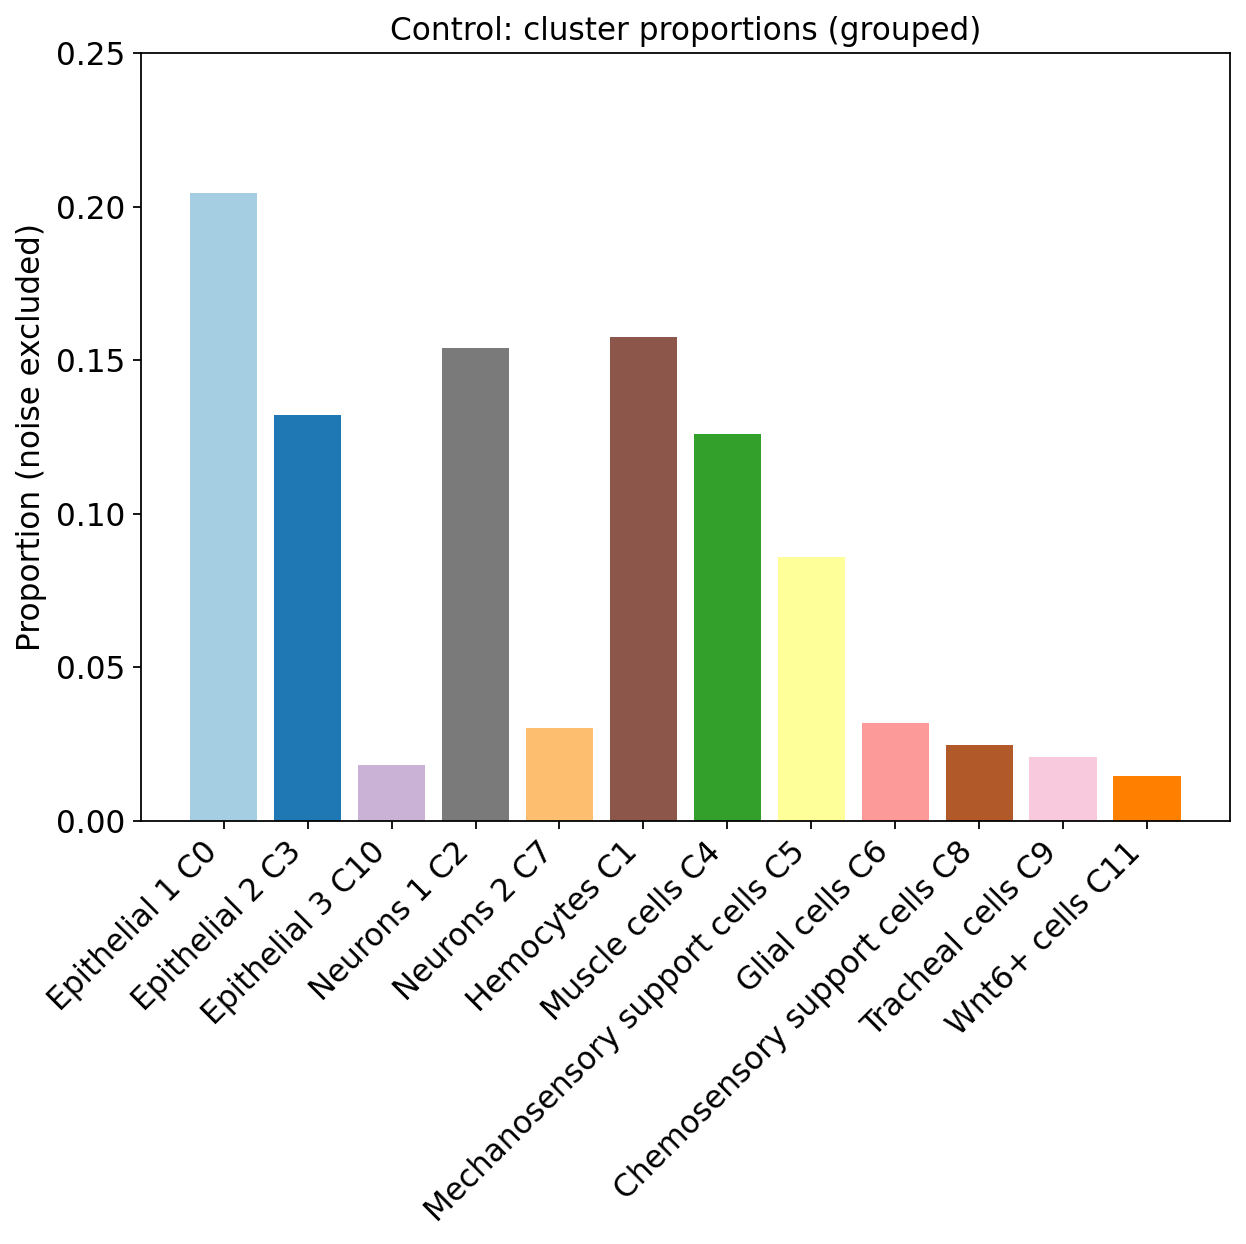

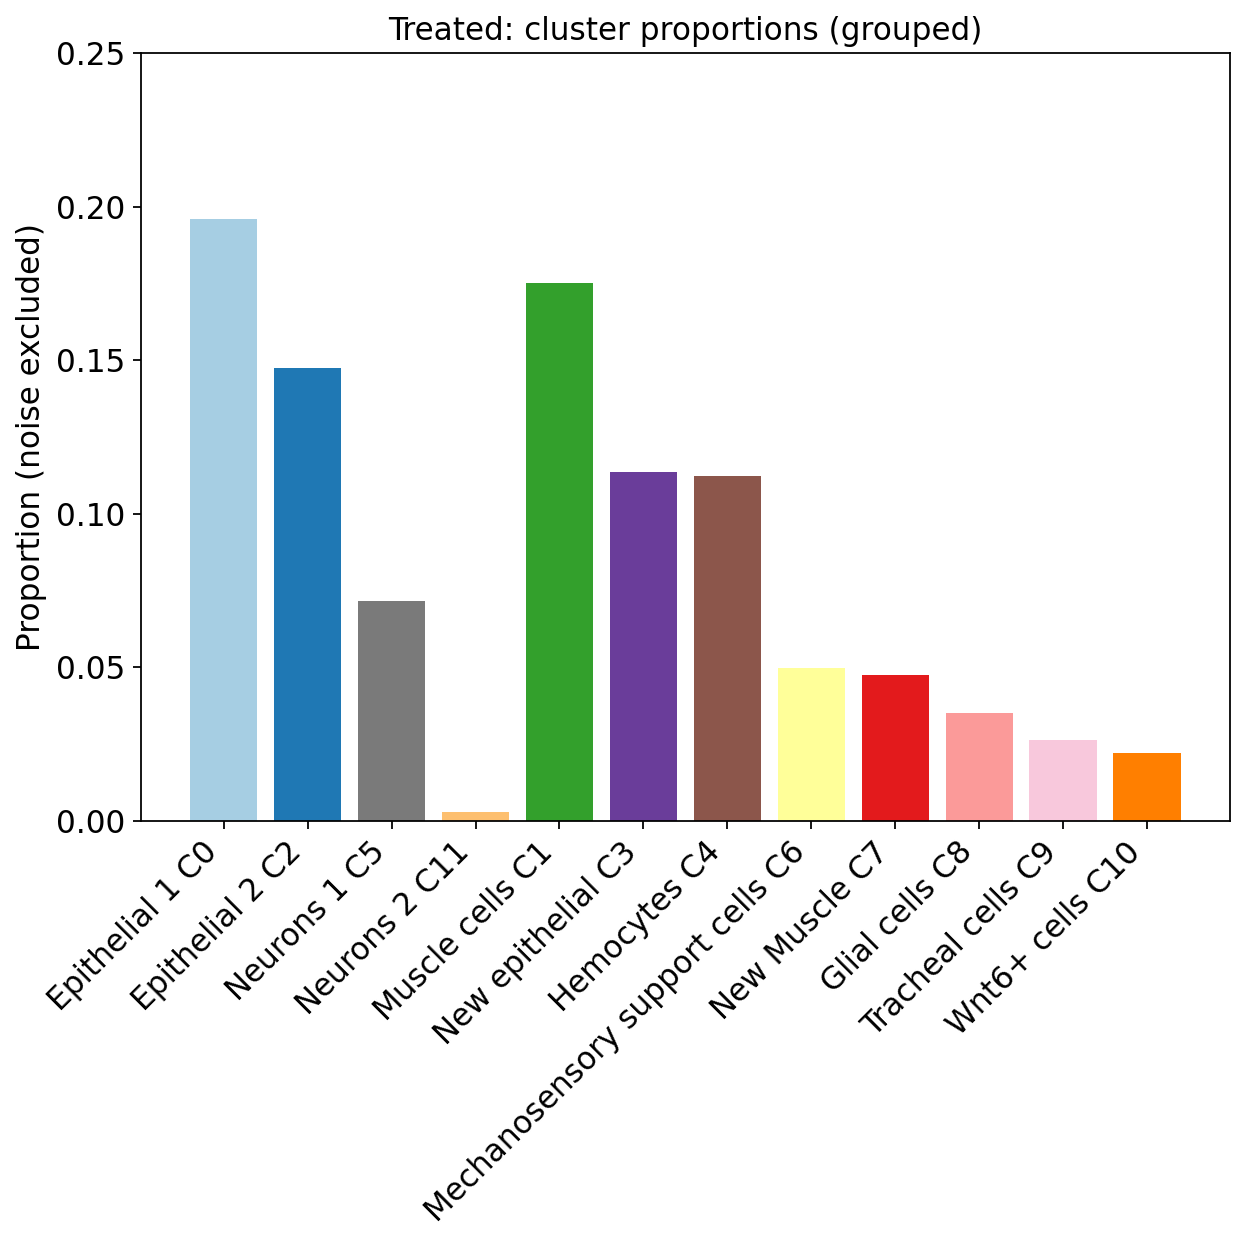

In [248]:
GROUP_ORDER = ["Epithelial", "Hemocytes", "Neurons","Muscle","Other"]

def _group_from_label(label):
    if label.startswith("Epithelial"):
        return "Epithelial"
    if label.startswith("Neurons"):
        return "Neurons"
    return "Other"


def plot_proportion_grouped(
    adata,
    title,
    cluster_map,
    drop="noise",
    savepath=None
):
    df = adata.obs[["leiden"]].copy()
    df["leiden"] = df["leiden"].astype(int)

    df["label"] = df["leiden"].astype(str).map(cluster_map)

    df = df[df["label"].notna()]
    df = df[df["label"] != drop]

    out = (
        df["leiden"].value_counts(normalize=True)
          .rename_axis("leiden")
          .reset_index(name="prop")
    )

    out["label"] = out["leiden"].astype(str).map(cluster_map)
    out["group"] = out["label"].apply(_group_from_label)
    out["group"] = pd.Categorical(out["group"], categories=GROUP_ORDER, ordered=True)

    out = out.sort_values(["group", "leiden"])

    labels = [f"{lab} C{leid}" for lab, leid in zip(out["label"], out["leiden"])]
    colors = [CELLTYPE_COLORS.get(lab, "grey") for lab in out["label"]]

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.bar(labels, out["prop"].values, color=colors)

    ax.set_ylim(0, 0.25)           # fixed y-axis
    ax.grid(False)                 # no grid
    ax.set_ylabel("Proportion (noise excluded)")
    ax.set_title(title)

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, format="pdf")   # Illustrator-friendly vector

    plt.show()


plot_proportion_grouped(adata_control, "Control: cluster proportions (grouped)", CONTROL_MAP)
plot_proportion_grouped(adata_treated, "Treated: cluster proportions (grouped)", TREATED_MAP)


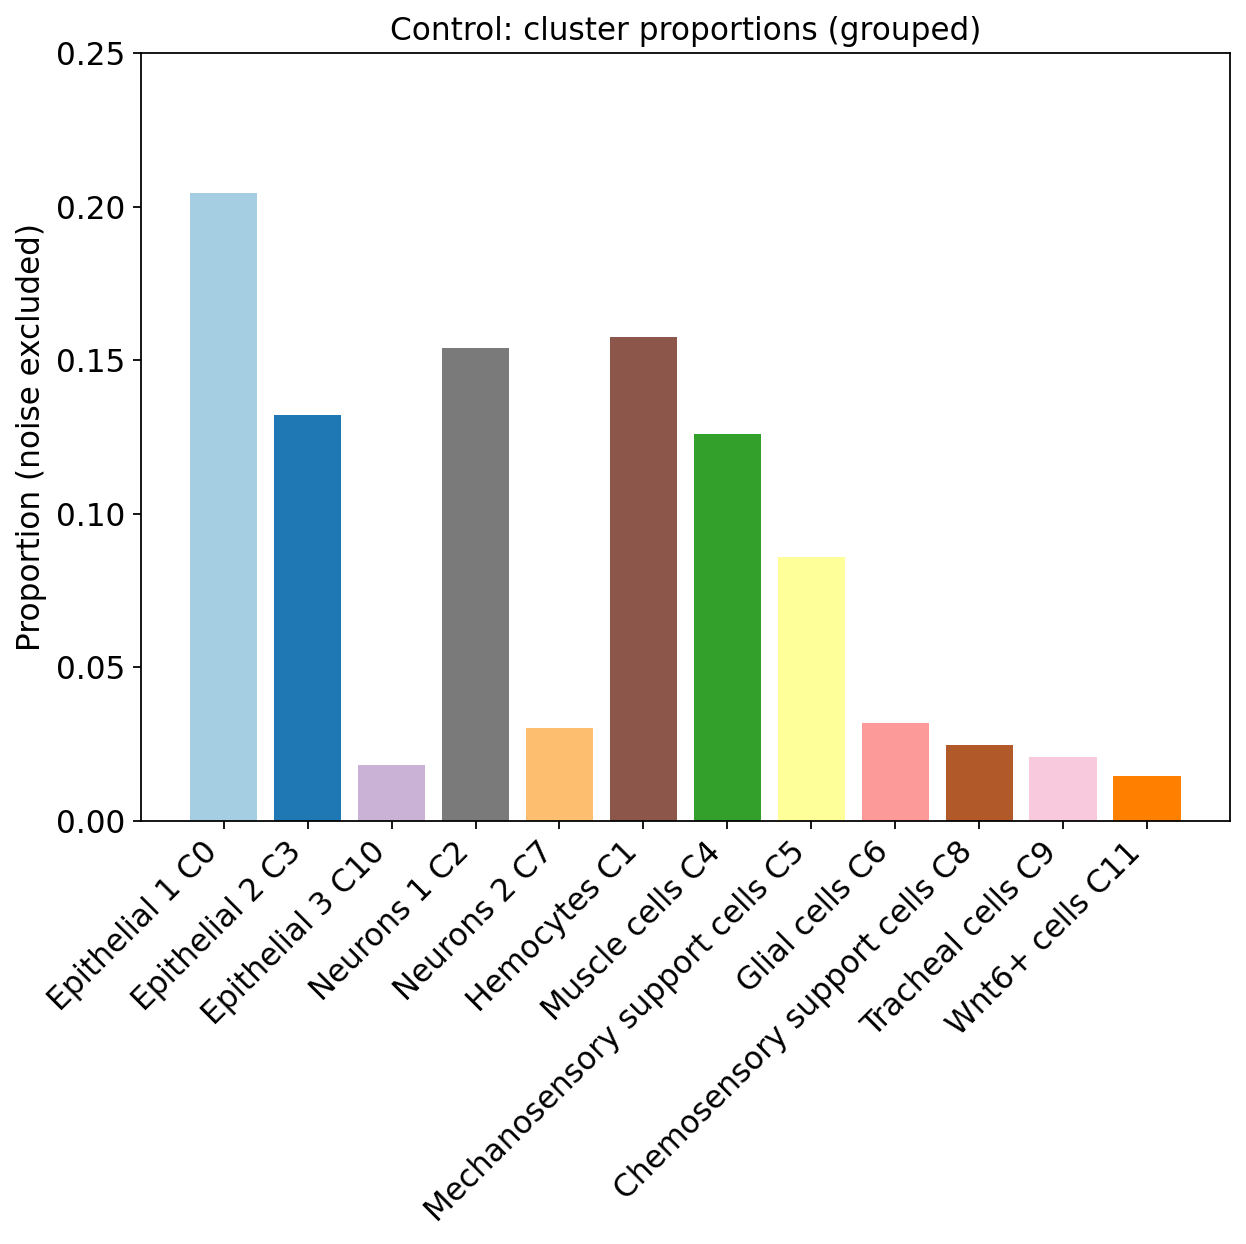

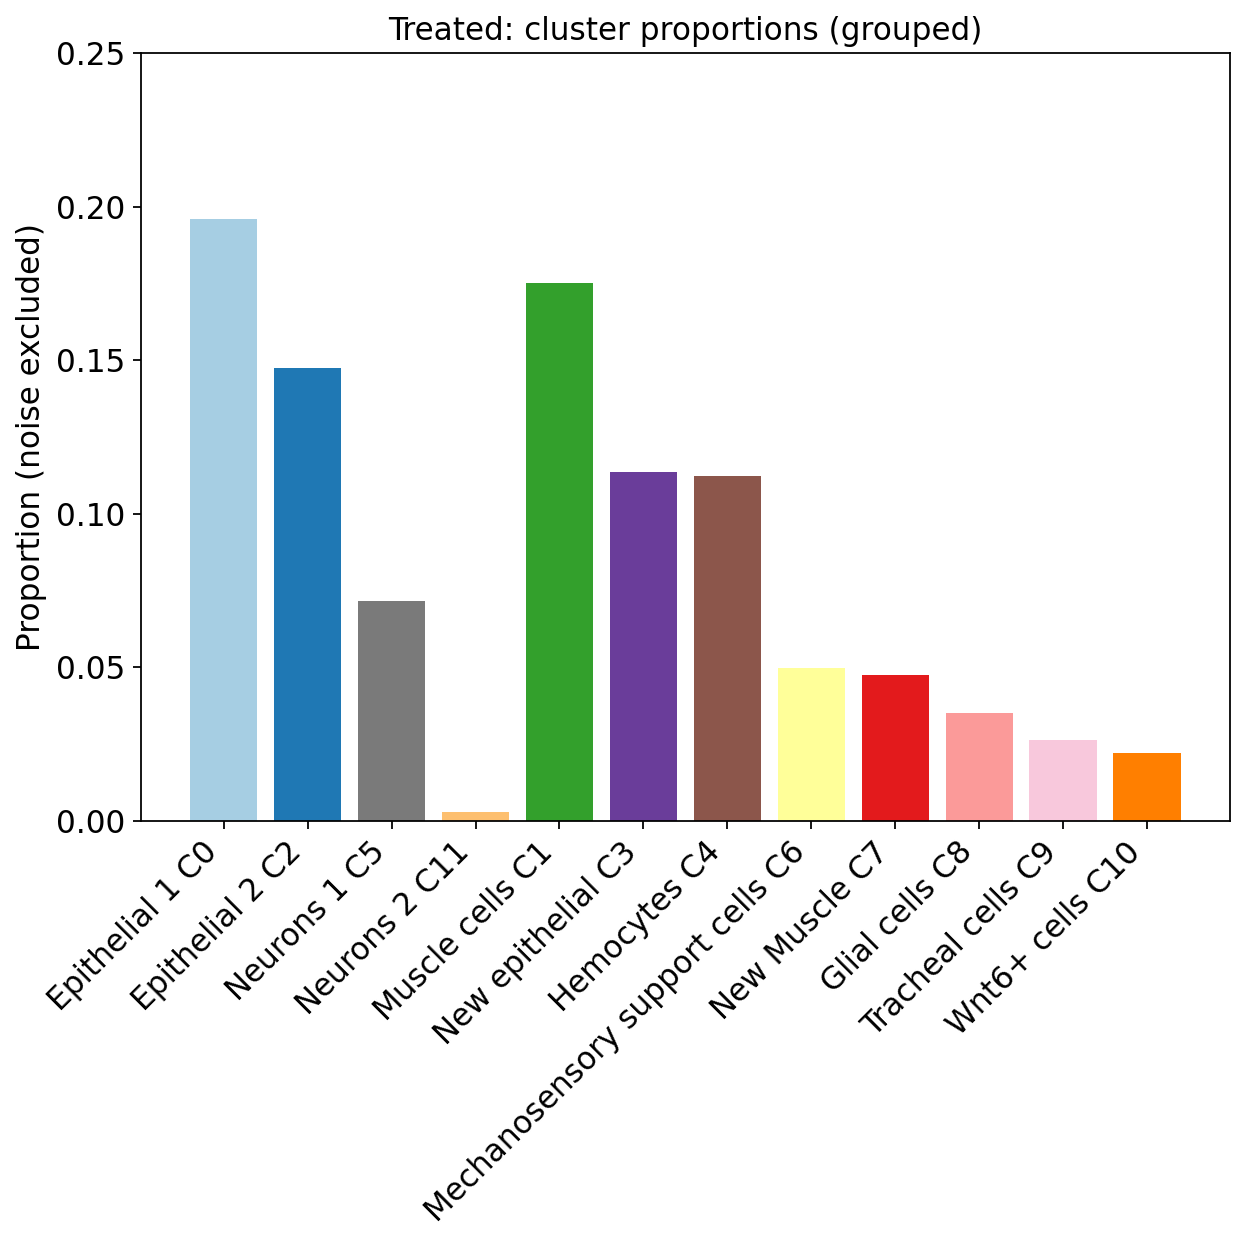

In [249]:
plot_proportion_grouped(
    adata_control,
    "Control: cluster proportions (grouped)",
    CONTROL_MAP,
    savepath="control_cluster_proportions.pdf"
)

plot_proportion_grouped(
    adata_treated,
    "Treated: cluster proportions (grouped)",
    TREATED_MAP,
    savepath="treated_cluster_proportions.pdf"
)
